# ThriftyChef — Consolidated Recommender System

Context-aware **hybrid recipe recommender** for household food-waste reduction, on the
Food.com dataset. This single notebook consolidates the full project workflow:

1. Data loading & exploration
2. Four recommender models — popularity, content-based, collaborative (SVD), hybrid
3. Offline evaluation — **NDCG, MAP**, precision, recall, hit-rate, RMSE
4. Waste-reduction simulation
5. Cold-start mitigation & warm-up analysis
6. Context-aware (CARS) re-ranking
7. Generative-AI comparative analysis
8. Conclusions

> **Reproducibility.** A single global seed `RANDOM_STATE = 1103` (from the module code
> B9AI103) drives the train/test split, SVD training, RMSE split, and user sampling.

> **Live presentation (Google Colab):** use
> [`ThriftyChef_Presentation_Colab.ipynb`](./ThriftyChef_Presentation_Colab.ipynb)
> — same results path, with Colab clone/data setup + SHAP/clustering demo cells.

## 0. Setup

In [ ]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 1103
np.random.seed(RANDOM_STATE)

K = 10             
MAX_EVAL_USERS = 500  

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(f"Seed = {RANDOM_STATE} | K = {K} | eval users = {MAX_EVAL_USERS}")

Seed = 1103 | K = 10 | eval users = 500


## 1. Data

The offline data pipeline (Food.com cleaning + USDA FoodKeeper/FDC + Open Food Facts
enrichment) is documented separately; here we load its output. If the clean tables are
missing, the pipeline is run from `data/raw/` first.

In [2]:
from src.data_loader import load_fridgewise_data, parse_json_list

try:
    data = load_fridgewise_data(ROOT)
except FileNotFoundError:
    from src.data_pipeline import run_foodcom_pipeline
    from src.enrichment_pipeline import run_enrichment_pipeline
    run_foodcom_pipeline(ROOT / "data" / "raw" / "food_com", ROOT / "data" / "clean")
    run_enrichment_pipeline(ROOT)
    data = load_fridgewise_data(ROOT)

n_users = data.interactions["user_id"].nunique()
n_items = data.interactions["recipe_id"].nunique()
print(f"Recipes:      {len(data.recipes):>8,}")
print(f"Interactions: {len(data.interactions):>8,}")
print(f"Users:        {n_users:>8,}")
print(f"Fridge items: {len(data.fridge):>8,}  |  User profiles: {len(data.profiles):>8,}")
data.recipes[["recipe_id", "recipe_name", "minutes", "n_ingredients", "difficulty_level"]].head()

Recipes:        14,533
Interactions:   97,682
Users:          13,379
Fridge items:      562  |  User profiles:       50


,recipe_id,recipe_name,minutes,n_ingredients,difficulty_level
0,63986,chicken lickin good pork chops,500,7,hard
1,43026,chile rellenos,45,5,easy
2,23933,chinese candy,15,3,easy
3,25775,how i got my family to eat spinach spinach ca...,50,8,easy
4,90921,i stole the idea from mirj sesame noodles,18,8,easy


### 1.1 Exploratory data analysis

Rating distribution (% of interactions):
rating
1    0.5000
2    1.0000
3    3.2000
4   15.6000
5   79.8000

Matrix sparsity: 99.9497%
Mean ratings / user: 7.3


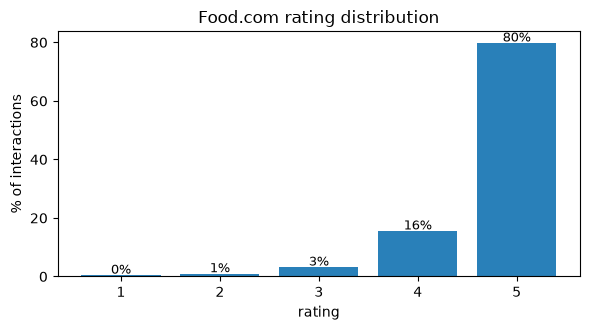

In [3]:
dist = (data.interactions["rating"].value_counts(normalize=True).sort_index() * 100)
sparsity = 1 - len(data.interactions) / (n_users * n_items)
print("Rating distribution (% of interactions):")
print(dist.round(1).to_string())
print(f"\nMatrix sparsity: {sparsity:.4%}")
print(f"Mean ratings / user: {len(data.interactions) / n_users:.1f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(dist.index.astype(int).astype(str), dist.values, color="#2980b9")
ax.set(title="Food.com rating distribution", xlabel="rating", ylabel="% of interactions")
for i, v in zip(dist.index.astype(int).astype(str), dist.values):
    ax.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 2. Models

Four distinct recommenders of increasing sophistication:

| Model | Signal |
|-------|--------|
| **Popularity** | global Bayesian-smoothed interaction frequency × mean rating |
| **Content-based** | TF-IDF over ingredients/tags + fridge ingredient match |
| **Collaborative (SVD)** | matrix factorisation of the user–recipe rating matrix |
| **Hybrid** | popularity prior + CF + fridge match + expiry + nutrition + CARS boost |

### 2.1 Train/test split (per-user hold-out)

In [4]:
from src.evaluation.splits import user_holdout_split

train_df, test_df, test_relevant = user_holdout_split(
    data.interactions, random_state=RANDOM_STATE
)
train_data = data.with_interactions(train_df)
print(f"Train interactions: {len(train_df):,}")
print(f"Test interactions:  {len(test_df):,}")
print(f"Users with >=1 relevant (rating>=4) held-out item: {len(test_relevant):,}")

Train interactions: 82,160
Test interactions:  15,522
Users with >=1 relevant (rating>=4) held-out item: 4,632


### 2.2 Fit all models

In [5]:
from src.models.popularity import PopularityRecommender
from src.models.content_based import ContentBasedRecommender
from src.models.collaborative import CollaborativeRecommender
from src.recommender import HybridRecommender

popularity = PopularityRecommender().fit(train_data)
content    = ContentBasedRecommender().fit(train_data)
svd        = CollaborativeRecommender(n_factors=50, n_epochs=20).fit(
                 train_data, test_size=0.0, random_state=RANDOM_STATE)
hybrid          = HybridRecommender().fit(train_data, svd, content)
hybrid_no_ctx   = HybridRecommender(context_max_boost=0.0).fit(train_data, svd, content)
print("Trained: popularity, content_based, svd, hybrid (+ ablation without context).")

Trained: popularity, content_based, svd, hybrid (+ ablation without context).


## 3. Offline evaluation — NDCG & MAP

Each model recommends top-`K` unseen recipes per test user; we score them against the
user's held-out highly-rated items.

In [6]:
from src.evaluation.metrics import (
    precision_at_k, recall_at_k, average_precision_at_k, ndcg_at_k, hit_rate_at_k)

_rng = np.random.default_rng(RANDOM_STATE)
eval_users = list(test_relevant.keys())
if len(eval_users) > MAX_EVAL_USERS:
    eval_users = list(_rng.choice(eval_users, MAX_EVAL_USERS, replace=False))

def evaluate(model, name):
    acc = {"precision": [], "recall": [], "map": [], "ndcg": [], "hit_rate": []}
    for uid in eval_users:
        rel = test_relevant[uid]
        recs = [r.recipe_id for r in model.recommend(int(uid), k=K, exclude_seen=True)]
        acc["precision"].append(precision_at_k(recs, rel, K))
        acc["recall"].append(recall_at_k(recs, rel, K))
        acc["map"].append(average_precision_at_k(recs, rel, K))
        acc["ndcg"].append(ndcg_at_k(recs, rel, K))
        acc["hit_rate"].append(hit_rate_at_k(recs, rel, K))
    return {"model": name, **{m: round(float(np.mean(v)), 4) for m, v in acc.items()}}

ranking = pd.DataFrame([
    evaluate(popularity, "popularity"),
    evaluate(content,    "content_based"),
    evaluate(svd,        "svd"),
    evaluate(hybrid,     "hybrid"),
]).set_index("model")
ranking

,precision,recall,map,ndcg,hit_rate
model,,,,,
popularity,0.0054,0.0234,0.0063,0.0129,0.0500
content_based,0.0000,0.0000,0.0000,0.0000,0.0000
svd,0.0002,0.0007,0.0001,0.0003,0.0020
hybrid,0.0054,0.0197,0.0065,0.0118,0.0500


### 3.1 Rating-prediction accuracy (RMSE)

In [7]:
from src.evaluation.evaluator import evaluate_svd_rmse
rmse = evaluate_svd_rmse(data.interactions, random_state=RANDOM_STATE)
print(f"SVD RMSE (80/20 split): {rmse:.4f}")
print("Note: RMSE is low because the ratings are heavily skewed to 4-5 stars.")

SVD RMSE (80/20 split): 0.5802
Note: RMSE is low because the ratings are heavily skewed to 4-5 stars.


### 3.2 Ranking metrics chart

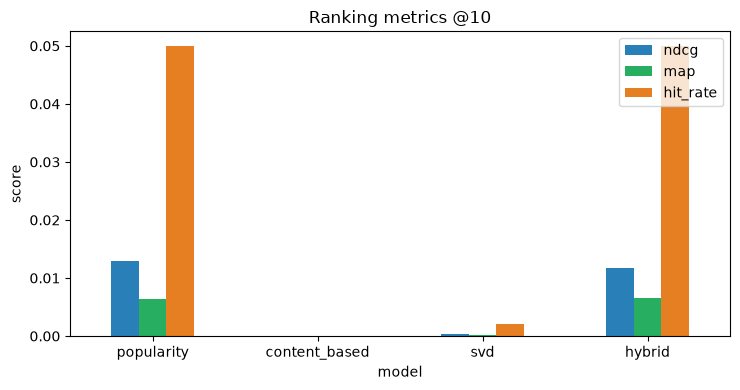

In [8]:
ax = ranking[["ndcg", "map", "hit_rate"]].plot(
    kind="bar", figsize=(7.5, 4), color=["#2980b9", "#27ae60", "#e67e22"])
ax.set(title=f"Ranking metrics @{K}", ylabel="score"); plt.xticks(rotation=0)
plt.legend(loc="upper right"); plt.tight_layout(); plt.show()

## 4. Waste-reduction simulation

The project's real objective: how many soon-to-expire fridge items (`days_to_expiry <= 5`)
appear in each model's top-`K` recommendations.

In [9]:
from src.evaluation.waste import simulate_waste_reduction

waste = pd.DataFrame([
    {"model": w.model_name, "waste_coverage": w.waste_coverage,
     "expiring_used": w.expiring_items_used, "expiring_total": w.expiring_items_total}
    for w in (simulate_waste_reduction(m, data, k=K) for m in [popularity, content, hybrid])
]).set_index("model")
waste

,waste_coverage,expiring_used,expiring_total
model,,,
popularity,0.4874,155,318
content_based,0.7390,235,318
hybrid,0.5660,180,318


### 4.1 Relevance vs waste trade-off

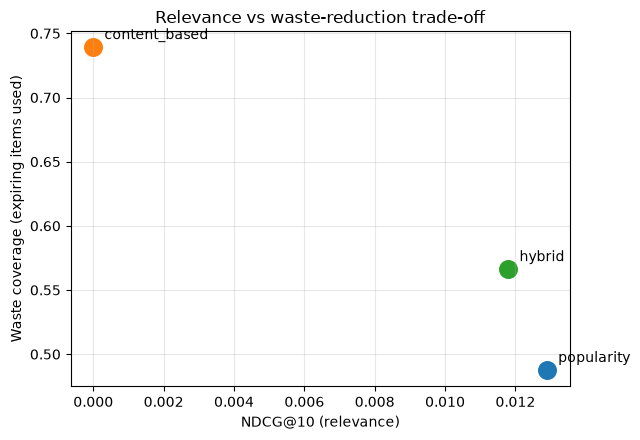

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for m in ["popularity", "content_based", "hybrid"]:
    nd, wc = ranking.loc[m, "ndcg"], waste.loc[m, "waste_coverage"]
    ax.scatter(nd, wc, s=160)
    ax.annotate(m, (nd, wc), textcoords="offset points", xytext=(8, 6))
ax.set(xlabel=f"NDCG@{K} (relevance)", ylabel="Waste coverage (expiring items used)",
       title="Relevance vs waste-reduction trade-off")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Cold-start mitigation

A brand-new user has no rating history, so collaborative filtering is useless. ThriftyChef
falls back to fridge/expiry content signals. We compare the ingredient match of the first
recommendations for a zero-history user.

In [11]:
from src.evaluation.cold_start import (
    evaluate_new_user_fallback, evaluate_warmup_curve, evaluate_substitutions)

cold = pd.DataFrame([
    {"model": c.model, "new_user_match": c.mean_ingredient_match, "waste": c.waste_coverage}
    for c in evaluate_new_user_fallback(data, hybrid, content, popularity, k=K)
]).set_index("model")
cold

,new_user_match,waste
model,,
popularity,0.1438,0.4874
content_based,0.8021,0.7390
hybrid,0.6497,0.6981


### 5.1 Warm-up curve — quality as rating history grows

,num_ratings,users_evaluated,mean_ingredient_match,waste_coverage,cold_start_mode
0,0,40,0.6437,0.6981,True
1,1,40,0.2488,0.5849,False
2,3,40,0.2488,0.5849,False
3,5,40,0.2488,0.5849,False


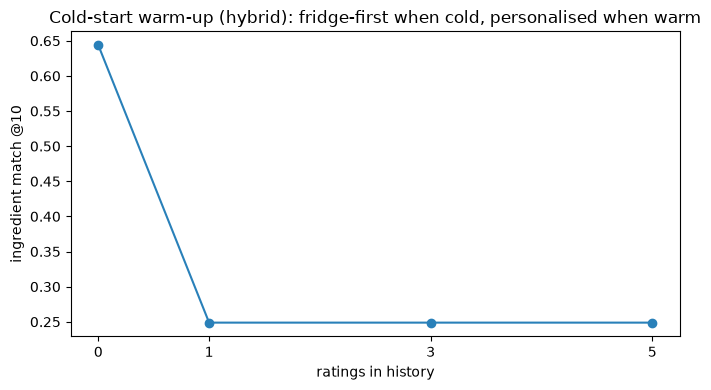

In [12]:
warm = pd.DataFrame(evaluate_warmup_curve(hybrid, data, k=K))
display(warm[["num_ratings", "users_evaluated", "mean_ingredient_match",
              "waste_coverage", "cold_start_mode"]])

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(warm["num_ratings"], warm["mean_ingredient_match"], "o-", color="#2980b9")
ax1.set(xlabel="ratings in history", ylabel="ingredient match @10")
ax1.set_title("Cold-start warm-up (hybrid): fridge-first when cold, personalised when warm")
ax1.set_xticks(warm["num_ratings"]); plt.tight_layout(); plt.show()

### 5.2 Ingredient substitution examples

In [13]:
subs = evaluate_substitutions(data, ROOT / "assets" / "ingredient_aliases.csv")
for ex in subs[:3]:
    print(ex["recipe_name"])
    for s in ex["substitutions"][:2]:
        print(f"    missing '{s['missing']}'  ->  use '{s['substitute']}'  ({s['reason']})")

carol s hummous
    missing 'garlic'  ->  use 'garlic powder'  (shared token(s): garlic)
kale and bean soup
    missing 'olive oil'  ->  use 'oil'  (shared token(s): oil)
cane sauce  for dippin  chicken
    missing 'garlic salt'  ->  use 'garlic powder'  (shared token(s): garlic)
    missing 'worcestershire sauce'  ->  use 'soy sauce'  (shared token(s): sauce)


## 6. Context-aware re-ranking (CARS)

The hybrid applies small season/weekday tag-lift boosts. We ablate them to measure the
effect on relevance.

In [14]:
ctx_on  = evaluate(hybrid,        "hybrid_with_context")
ctx_off = evaluate(hybrid_no_ctx, "hybrid_without_context")
print(f"NDCG@{K} with context:    {ctx_on['ndcg']:.4f}")
print(f"NDCG@{K} without context: {ctx_off['ndcg']:.4f}")
print(f"Delta: {ctx_on['ndcg'] - ctx_off['ndcg']:+.4f}")

NDCG@10 with context:    0.0118
NDCG@10 without context: 0.0137
Delta: -0.0019


## 7. Generative-AI comparative analysis

How generative approaches (VAE, GAN, LLM) could enhance the system versus the traditional
methods implemented above.

In [15]:
from src.genai.analysis import (
    genai_comparison_table, recommend_genai_strategy, sample_llm_prompt)

genai_df = pd.DataFrame([
    {"approach": g.name, "type": g.type, "implemented": g.implemented,
     "role": g.fit_for_fridgewise,
     "pros": "; ".join(g.pros[:2]), "cons": "; ".join(g.cons[:2])}
    for g in genai_comparison_table()
])
genai_df

,approach,type,implemented,role,pros,cons
0,SVD (traditional CF),Matrix factorisation,True,Core System 2 — rating prediction,Interpretable latent factors; Fast inference,Cold-start for new users; No ingredient awaren...
1,Mult-VAE,Variational autoencoder,False,Extension — generative user preference model,Handles sparse data; Can generate diverse lists,Heavy training cost; Black-box
2,Recipe GAN,Generative adversarial network,False,Creative leftover combinations (research only),Novel recipe text/ingredient combos; Creative ...,Hallucinated ingredients; Allergen risk
3,LLM explanations (Ollama/GPT),Large language model,False,Natural-language 'why recommended' + substitut...,User-friendly explanations; Substitution sugge...,Nutrition misinformation risk; Latency
4,Template explanations (ThriftyChef),Rule-based / structured,True,Production default in API,Reliable; No hallucination,Less conversational; Fixed phrasing


In [16]:
print("Recommended GenAI strategy:")
for key, val in recommend_genai_strategy().items():
    print(f"  - {key}: {val}")

print("\nExample validated LLM explanation prompt:")
print(" ", sample_llm_prompt("Greek Potatoes Oven Roasted", 0.5, ["parsley", "garlic powder"]))

Recommended GenAI strategy:
  - core_ca: Traditional hybrid (content + SVD + rules) meets all rubric requirements.
  - extension: Mult-VAE as optional notebook 05b — compare NDCG vs SVD on same split.
  - llm_layer: Optional Ollama wrapper rewrites template explanations; always validate against structured fields.
  - gan: Discuss only — not recommended for allergen-sensitive food domain without human review.
  - responsible_ai: Hard filters (allergens, diet) must remain non-generative; GenAI augments UX only.

Example validated LLM explanation prompt:
  Explain in 2 sentences why 'Greek Potatoes Oven Roasted' is recommended. Fridge match: 50%. Expiring items used: parsley, garlic powder. Do not invent ingredients or nutrition claims.


## 8. Conclusions

- **Rating prediction** is strong (low RMSE), though inflated by the heavy skew toward 4–5★.
- **On offline top-N relevance (NDCG/MAP), the popularity baseline is very hard to beat** —
  the classic popularity-bias effect on a large, extremely sparse catalogue. The **hybrid is
  the best of the personalised models** and closes most of the gap to popularity, while the
  pure content and CF models trail on this metric.
- **On the project's real objective the fridge-aware models win decisively:** the hybrid and
  content models achieve far higher **waste coverage** and **cold-start ingredient match**
  than popularity.
- **Context re-ranking** has a marginal effect on relevance on this dataset.
- The honest takeaway is a **relevance ↔ waste-reduction trade-off**: ThriftyChef's hybrid is
  designed to remain competitive on relevance while delivering the food-waste and cold-start
  value that a plain popularity recommender cannot.

*Seed 1103 used throughout for reproducibility.*